**Problem definition**

This notebook extends `hybrid_corrector.ipynb`. The problem and geometry remain the same. The goal is to train a CNN as an *accelerator*, rather than a *corrector*. Its prediction will be used as the initial guess for the Jacobi solver, reducing the number of iterations required.

The target solution is the same as before. We also add another higher-frequency solution, to discuss further the spectral behaviour of numerical and hybrid solvers.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

torch.manual_seed(42)
np.random.seed(42)

Domain and solutions:

In [2]:
N = 32  # interior grid points per side
h = 1.0 / (N + 1)  # uniform grid spacing

coords = np.linspace(0, 1, N + 2)
X, Y = np.meshgrid(coords, coords)

### Reference problem: exact solution u* = sin(pi x)sin(pi y)
u_star = np.sin(np.pi * X) * np.sin(np.pi * Y)
f_ref = 2.0 * np.pi**2 * u_star

### Reference problem, high frequency: u*_hf = u* + sin(4 pi x) sin(4 pi y)
u_star_hf = np.sin(4 * np.pi * X) * np.sin(4 * np.pi * Y) + u_star
f_ref_hf = 32 * np.pi**2 * np.sin(4 * np.pi * X) * np.sin(4 * np.pi * Y) + f_ref

Numerical solvers and helpers:

In [3]:
def jacobi_step(u, f):
    """Jacobi solver step on interior points (boundary stays zero)."""
    u_new = u.copy()
    u_new[1:-1, 1:-1] = 0.25 * (
        u[:-2, 1:-1] + u[2:, 1:-1] + u[1:-1, :-2] + u[1:-1, 2:] + h**2 * f[1:-1, 1:-1]
    )
    return u_new

def residual(u, f):
    """r = f − Au,  where A is the 2D finite-difference Laplacian."""
    Au = np.zeros_like(u)
    Au[1:-1, 1:-1] = (
        4 * u[1:-1, 1:-1] - u[:-2, 1:-1] - u[2:, 1:-1] - u[1:-1, :-2] - u[1:-1, 2:]
    ) / h**2
    return f - Au

def relative_error(u, us=None):
    if us is None:
        return np.linalg.norm(u - u_star) / np.linalg.norm(u_star)
    else:
        return np.linalg.norm(u - us) / np.linalg.norm(us)

def run_jacobi(f, n_steps, us=None):
    """Jacobi solver, returns final u and per-step relative error history."""
    u = np.zeros((N + 2, N + 2))
    errors = []
    for _ in range(n_steps):
        u = jacobi_step(u, f)
        errors.append(relative_error(u, us))
    return u, errors

In [4]:
def exact_solve(f):
    """
    Direct sparse solve for the Poisson equation on the N×N interior.
    Used to get ground-truth solutions for training problems.
    """
    n = N * N
    diag_main = 4.0 * np.ones(n)
    diag_off1 = -1.0 * np.ones(n - 1)
    diag_off1[np.arange(N - 1, n - 1, N)] = 0.0
    diag_offN = -1.0 * np.ones(n - N)

    A = (
        diags(
            [diag_offN, diag_off1, diag_main, diag_off1, diag_offN],
            [-N, -1, 0, 1, N],
            format="csc",
        )
        / h**2
    )

    u_int = spsolve(A, f[1:-1, 1:-1].ravel()).reshape(N, N)
    u = np.zeros((N + 2, N + 2))
    u[1:-1, 1:-1] = u_int
    return u


def random_smooth_rhs():
    """Random right hand side, sum of low-frequency sine modes."""
    f = np.zeros((N + 2, N + 2))
    for k in range(1, 5):
        for l in range(1, 5):
            f += np.random.randn() * np.sin(k * np.pi * X) * np.sin(l * np.pi * Y)
    return f

Data generation:

In [5]:
def generate_training_data(n_problems=500):
    """
    The CNN is given as output the right hand side, and predicts the solution.
    This teaches the CNN to produce a reasonable initial guess
    that Jacobi can then refine efficiently.
    """
    print(f"Generating {n_problems} training points...")
    f_list, u_list = [], []

    for _ in range(n_problems):
        f = random_smooth_rhs()
        u_ref = exact_solve(f)

        # CNN input:  right-hand side f (interior only)
        # CNN output: exact solution u_ref (interior only)
        f_int = f[1:-1, 1:-1]
        u_int = u_ref[1:-1, 1:-1]

        # Per-sample normalisation
        scale = np.sqrt(np.mean(f_int**2)) + 1e-10
        f_list.append(f_int / scale)
        u_list.append(u_int / scale)  # output scaled by same factor
    print("Data created.")
    return (
        np.array(f_list, dtype=np.float32),
        np.array(u_list, dtype=np.float32),
    )

In [6]:
# | output: false
f, u = generate_training_data(n_problems=1000)
X_train = torch.from_numpy(f[:, None])
Y_train = torch.from_numpy(u[:, None])

Generating 1000 training points...
Data created.


CNN creation:

In [7]:
class InitialGuess(nn.Module):
    """
    CNN model:
      Input: source term (N×N), Output:prediction used as initial guess (N×N)
    Skip connection added for stability.
    """

    def __init__(self):
        Nloc = 32
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, Nloc, 3, padding=1),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(Nloc, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 1, 3, padding=1),
        )

    def forward(self, x):
        # Add skip connection
        return self.decoder(self.encoder(x)) + x

Training:

In [8]:
# | output: false

model = InitialGuess()
optimiser = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimiser, step_size=30, gamma=0.5)
loss_fn = nn.MSELoss()

dataset = torch.utils.data.TensorDataset(X_train, Y_train)
loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

n_epochs = 150
print(f"Training CNN for {n_epochs} epochs...")

for epoch in range(n_epochs):
    epoch_loss = 0.0
    for xb, yb in loader:
        pred = model(xb)
        loss = loss_fn(pred, yb)
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()
        epoch_loss += loss.item()
    scheduler.step()
    if (epoch + 1) % 10 == 0:
        print(f"  epoch {epoch+1:3d}/{n_epochs}  loss = {epoch_loss/len(loader):.5f}")

Training CNN for 150 epochs...
  epoch  10/150  loss = 0.00057
  epoch  20/150  loss = 0.00019
  epoch  30/150  loss = 0.00031
  epoch  40/150  loss = 0.00010
  epoch  50/150  loss = 0.00010
  epoch  60/150  loss = 0.00009
  epoch  70/150  loss = 0.00008
  epoch  80/150  loss = 0.00007
  epoch  90/150  loss = 0.00007
  epoch 100/150  loss = 0.00007
  epoch 110/150  loss = 0.00006
  epoch 120/150  loss = 0.00006
  epoch 130/150  loss = 0.00006
  epoch 140/150  loss = 0.00006
  epoch 150/150  loss = 0.00006


In [9]:
def apply_cnn_initial_guess(f):
    """
    CNN predicts an initial solution directly from the right-hand side f.
    """
    f_int = f[1:-1, 1:-1]
    scale = np.sqrt(np.mean(f_int**2)) + 1e-10

    inp = torch.from_numpy((f_int / scale)[None, None].astype(np.float32))
    with torch.no_grad():
        u_int = model(inp).squeeze().numpy() * scale

    u0 = np.zeros((N + 2, N + 2))
    u0[1:-1, 1:-1] = u_int
    return u0


def run_hybrid(f, n_steps, use_cnn_init=True, us=None):
    """
    Hybrid solver with CNN initial guess:
      - If use_cnn_init: start from CNN prediction
      - Else: start from zero (for comparison)
      - Then run pure Jacobi for n_steps
    """
    if use_cnn_init:
        u = apply_cnn_initial_guess(f)
    else:
        u = np.zeros((N + 2, N + 2))

    errors = [relative_error(u, us)]  # record initial error

    for step in range(n_steps):
        u = jacobi_step(u, f)
        errors.append(relative_error(u, us))

    return u, errors

In [10]:
# | output: false

### CNN prediction is used as initial guess
n_steps = 500
print("\nRunning solvers for comparison...")
u_jacobi, err_jacobi = run_jacobi(f_ref, n_steps)
u_hybrid, err_hybrid = run_hybrid(f_ref, n_steps, use_cnn_init=True)

print(f"  Jacobi only — initial error: {err_jacobi[0]:.3e}")
print(f"  Jacobi only — final error: {err_jacobi[-1]:.3e}")
print(f"  CNN init + Jacobi — initial error: {err_hybrid[0]:.3e}")
print(f"  CNN init + Jacobi — final error: {err_hybrid[-1]:.3e}")


Running solvers for comparison...
  Jacobi only — initial error: 9.955e-01
  Jacobi only — final error: 1.027e-01
  CNN init + Jacobi — initial error: 3.536e-01
  CNN init + Jacobi — final error: 3.542e-02


Now we plot the convergence curves of the Jacobi and hybrid solvers:

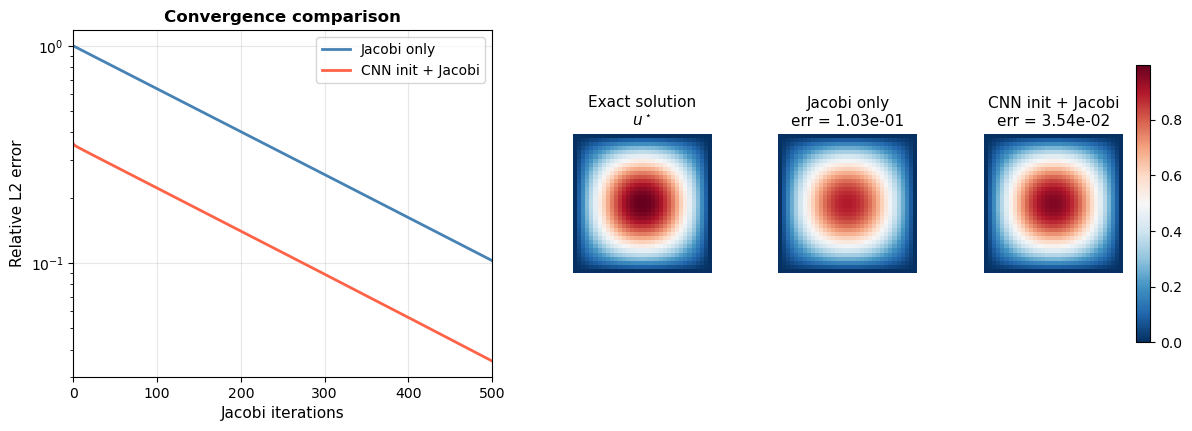

In [11]:
err_jacobi_full = [1.0] + err_jacobi  # zero initial guess has relative error 1.0
err_hybrid_full = err_hybrid  # already includes CNN initial guess

iters_full = np.arange(0, n_steps + 1)
iters_jacobi_only = np.arange(1, n_steps + 1)

fig = plt.figure(figsize=(15, 4.5))
gs = gridspec.GridSpec(1, 4, width_ratios=[2.5, 1, 1, 1], wspace=0.35)

ax_conv = fig.add_subplot(gs[0])
ax_star = fig.add_subplot(gs[1])
ax_jac = fig.add_subplot(gs[2])
ax_hyb = fig.add_subplot(gs[3])

### Convergence curves
ax_conv.semilogy(
    iters_full, err_jacobi_full, label="Jacobi only", color="steelblue", linewidth=2
)
ax_conv.semilogy(
    iters_full, err_hybrid_full, label="CNN init + Jacobi", color="tomato", linewidth=2
)

ax_conv.set_xlabel("Jacobi iterations", fontsize=11)
ax_conv.set_ylabel("Relative L2 error", fontsize=11)
ax_conv.set_title("Convergence comparison", fontsize=12, fontweight="bold")
ax_conv.legend(fontsize=10)
ax_conv.grid(True, alpha=0.3)
ax_conv.set_xlim(0, n_steps)

### Solution fields
vmin, vmax = u_star.min(), u_star.max()
kwargs_plot = dict(vmin=vmin, vmax=vmax, cmap="RdBu_r", origin="lower")

ax_star.imshow(u_star, **kwargs_plot)
ax_star.set_title("Exact solution\n$u^\\star$", fontsize=11)
ax_star.axis("off")

ax_jac.imshow(u_jacobi, **kwargs_plot)
ax_jac.set_title(f"Jacobi only\nerr = {err_jacobi[-1]:.2e}", fontsize=11)
ax_jac.axis("off")

im = ax_hyb.imshow(u_hybrid, **kwargs_plot)
ax_hyb.set_title(f"CNN init + Jacobi\nerr = {err_hybrid[-1]:.2e}", fontsize=11)
ax_hyb.axis("off")

plt.colorbar(im, ax=[ax_star, ax_jac, ax_hyb], shrink=0.8, pad=0.02)

plt.show()

We observe the same behaviour as with the corrector, with an error drop when the CNN is applied compared to pure Jacobi iterations. The accuracy reached is not satisfactory, but it is fed again into the solver until convergence. The initial guess head start reduces the number of Jacobi iterations by more than 200 for a given accuracy threshold.

Now, high frequency prediction:

In [12]:
# | output: false

### No retraining, inference on the high frequency case:
n_steps = 500
print("\nRunning solvers for comparison, high frequency case...")
u_jacobi_hf, err_jacobi_hf = run_jacobi(f_ref_hf, n_steps, us=u_star_hf)
u_hybrid_hf, err_hybrid_hf = run_hybrid(
    f_ref_hf, n_steps, use_cnn_init=True, us=u_star_hf
)

print(f"  Jacobi only - initial error: {err_jacobi_hf[0]:.3e}")
print(f"  Jacobi only - final error: {err_jacobi_hf[-1]:.3e}")
print(f"  CNN init + Jacobi — initial error: {err_hybrid_hf[0]:.3e}")
print(f"  CNN init + Jacobi — final error: {err_hybrid_hf[-1]:.3e}")


Running solvers for comparison, high frequency case...
  Jacobi only - initial error: 9.621e-01
  Jacobi only - final error: 7.314e-02
  CNN init + Jacobi — initial error: 2.058e+00
  CNN init + Jacobi — final error: 5.322e-02


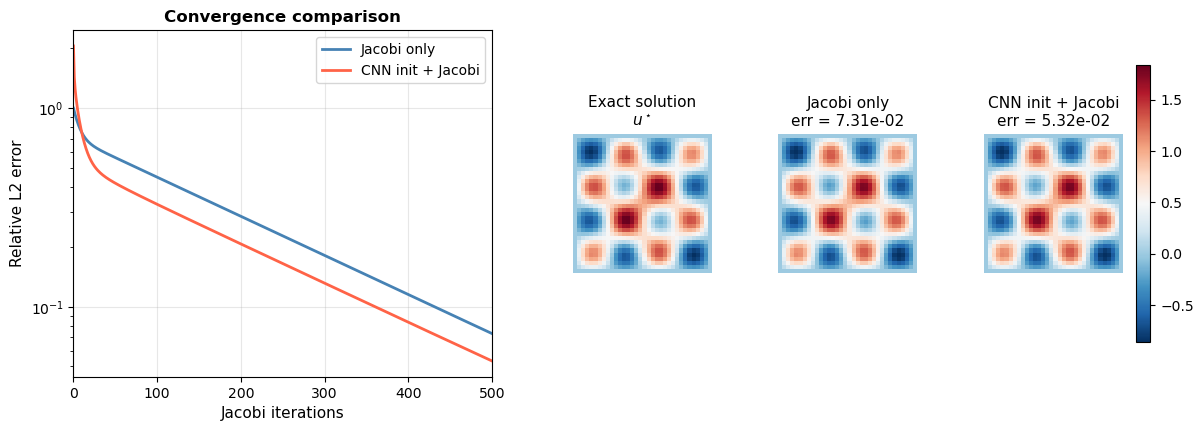

In [13]:
err_jacobi_full_hf = [1.0] + err_jacobi_hf
err_hybrid_full_hf = err_hybrid_hf

iters_full = np.arange(0, n_steps + 1)
iters_jacobi_only = np.arange(1, n_steps + 1)

fig = plt.figure(figsize=(15, 4.5))
gs = gridspec.GridSpec(1, 4, width_ratios=[2.5, 1, 1, 1], wspace=0.35)

ax_conv = fig.add_subplot(gs[0])
ax_star = fig.add_subplot(gs[1])
ax_jac = fig.add_subplot(gs[2])
ax_hyb = fig.add_subplot(gs[3])

### Convergence curves
ax_conv.semilogy(
    iters_full, err_jacobi_full_hf, label="Jacobi only", color="steelblue", linewidth=2
)
ax_conv.semilogy(
    iters_full,
    err_hybrid_full_hf,
    label="CNN init + Jacobi",
    color="tomato",
    linewidth=2,
)

ax_conv.set_xlabel("Jacobi iterations", fontsize=11)
ax_conv.set_ylabel("Relative L2 error", fontsize=11)
ax_conv.set_title("Convergence comparison", fontsize=12, fontweight="bold")
ax_conv.legend(fontsize=10)
ax_conv.grid(True, alpha=0.3)
ax_conv.set_xlim(0, n_steps)

### Solution fields
vmin, vmax = u_star_hf.min(), u_star_hf.max()
kwargs_plot = dict(vmin=vmin, vmax=vmax, cmap="RdBu_r", origin="lower")

ax_star.imshow(u_star_hf, **kwargs_plot)
ax_star.set_title("Exact solution\n$u^\\star$", fontsize=11)
ax_star.axis("off")

ax_jac.imshow(u_jacobi_hf, **kwargs_plot)
ax_jac.set_title(f"Jacobi only\nerr = {err_jacobi_hf[-1]:.2e}", fontsize=11)
ax_jac.axis("off")

im = ax_hyb.imshow(u_hybrid_hf, **kwargs_plot)
ax_hyb.set_title(f"CNN init + Jacobi\nerr = {err_hybrid_hf[-1]:.2e}", fontsize=11)
ax_hyb.axis("off")

plt.colorbar(im, ax=[ax_star, ax_jac, ax_hyb], shrink=0.8, pad=0.02)

plt.show()

Because of the high frequency component in the target solution, the CNN initial guess is worse than a zero initial guess, in terms of L2 error. However, this high frequency is dealt with in the first Jacobi iterations, and the CNN initial guess allows to reach a better accuracy after a few steps because it can fit the low frequency term, making it more accurate than the pure Jacobi solver.

If we removed the low-frequency term from the solution, using the CNN initial guess would then be detrimental. This illustrates that the structure of the hybrid solver should be designed carefully, based on the physical problem characteristics.